## Data Quality Check

In [3]:
import pandas as pd

df = pd.read_csv('scam_dataset.csv')

# ตรวจสอบข้อมูลว่าง (Missing Values)
missing_text = df['Text'].isnull().sum()
if missing_text > 0:
    print(f"พบแถวที่ไม่มีข้อความทั้งหมด: {missing_text} แถว")
    df = df.dropna(subset=['Text'])

# ตรวจสอบข้อมูลซ้ำ
duplicates = df.duplicated(subset=['Text']).sum()
if duplicates > 0:
    print(f" พบข้อมูลข้อความซ้ำกัน: {duplicates} แถว")
    df = df.drop_duplicates(subset=['Text'])

invalid_labels = df[~df['Label'].isin([0, 1])]
if not invalid_labels.empty:
    print(f" พบ Label ที่ผิดปกติ: {len(invalid_labels)} แถว")

print("\n สรุปจำนวนข้อมูลหลัง Clean")
print(df['Label'].value_counts())
print("-" * 30)

df.to_csv('scam_dataset_cleaned.csv', index=False)


 พบข้อมูลข้อความซ้ำกัน: 468 แถว

 สรุปจำนวนข้อมูลหลัง Clean
Label
0    390
1    384
Name: count, dtype: int64
------------------------------


### Train test split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("scam_dataset_cleaned.csv")

# แบ่ง Train ออกมา 70% และเก็บ Temp ไว้ 30%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["Label"], 
)
    
# เอา Temp 30% มาหั่นครึ่ง จะได้ Validation 15% and Test 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["Label"],
)

                  Normal(0)  Scam (1)
Train (70%)             273       268
Validation (15%)         58        58
Test (15%)               59        58
--------------------------------------------------


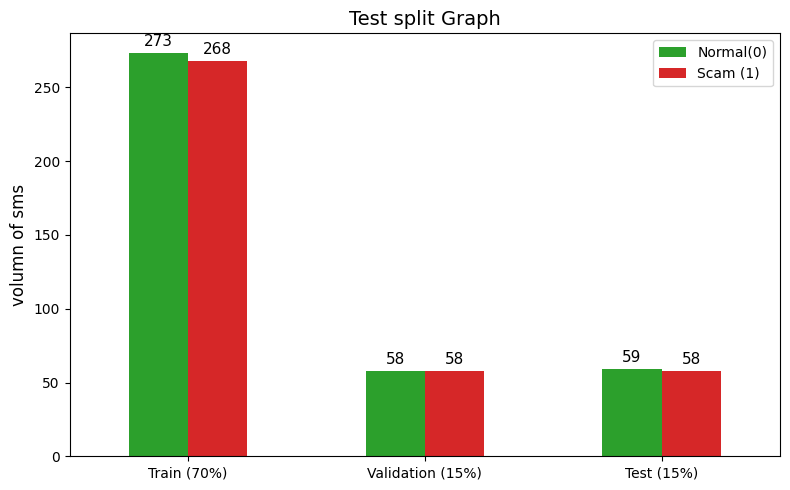

In [ ]:
import matplotlib.pyplot as plt

split_summary = pd.DataFrame({
    'Train (70%)': train_df['Label'].value_counts().sort_index(),
    'Validation (15%)': val_df['Label'].value_counts().sort_index(),
    'Test (15%)': test_df['Label'].value_counts().sort_index()
}).T

split_summary.columns = ['Normal(0)', 'Scam (1)']
print(split_summary)
print("-" * 50)

ax = split_summary.plot(kind='bar', figsize=(8, 5), color=['#2ca02c', '#d62728'], rot=0)

plt.title('Test split Graph', fontsize=14)
plt.ylabel('volumn of sms', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, 
                xytext=(0, 3), textcoords='offset points')

plt.tight_layout()

# plt.savefig('Tet_split_plot.png')

In [6]:
#Export csv
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("val_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print(" สรุป Test split:")
print(f" train data มีข้อมูล: {len(train_df)} แถว")
print(f" val data   มีข้อมูล: {len(val_df)} แถว ")
print(f" test data  มีข้อมูล: {len(test_df)} แถว ")

print("\n ตรวจสอบสัดส่วน (ปกติ 0, สแกม 1) ในไฟล์ Test Set:")
print(test_df["Label"].value_counts())

 สรุป Test split:
 train data มีข้อมูล: 541 แถว
 val data   มีข้อมูล: 116 แถว 
 test data  มีข้อมูล: 117 แถว 

 ตรวจสอบสัดส่วน (ปกติ 0, สแกม 1) ในไฟล์ Test Set:
Label
0    59
1    58
Name: count, dtype: int64
